In [ ]:
import sqlite3
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot-stil
sns.set_theme(style="whitegrid", context="talk")
pd.options.display.float_format = "{:.3f}".format

DB_PATH = Path.cwd().parent / "data" / "football.db"
conn = sqlite3.connect(DB_PATH)

# Last inn alt i en DataFrame – 56k rader er trivielt for pandas
df = pd.read_sql("SELECT * FROM matches", conn, parse_dates=["date"])
print(f"Lastet inn {len(df):,} kamper")
df.head()

In [ ]:
# Skala på dataene
print("Antall kamper per liga og sesong (de siste 5 sesongene):")
recent = df[df["season"] >= "2020-21"]
print(recent.groupby(["season", "league"]).size().unstack(fill_value=0))

In [ ]:
# Andel hjemmeseiere per sesong
home_win_rate = (
    df.assign(home_win=(df["result"] == "H").astype(int))
      .groupby(["season", "league"])["home_win"].mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=home_win_rate, x="season", y="home_win", hue="league", ax=ax, marker="o")
ax.set_title("Hjemmebanefordel over tid")
ax.set_ylabel("Andel hjemmeseiere")
ax.set_xlabel("Sesong")
ax.tick_params(axis="x", rotation=60)
ax.axhline(0.33, color="gray", linestyle="--", alpha=0.5, label="Tilfeldig (1/3)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
df["total_goals"] = df["home_goals"] + df["away_goals"]
df["home_goals"] = df["home_goals"].astype(float)
df["away_goals"] = df["away_goals"].astype(float)

goals_per_season = df.groupby(["season", "league"])[["home_goals", "away_goals", "total_goals"]].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=goals_per_season, x="season", y="total_goals", hue="league", ax=ax, marker="o")
ax.set_title("Gjennomsnittlig antall mål per kamp")
ax.set_ylabel("Mål per kamp")
ax.tick_params(axis="x", rotation=60)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
score_counts = (
    df.groupby(["home_goals", "away_goals"]).size()
      .reset_index(name="count")
)
# Begrens til kamper med <= 5 mål for hvert lag for lesbarhet
score_counts = score_counts[(score_counts["home_goals"] <= 5) & (score_counts["away_goals"] <= 5)]
pivot = score_counts.pivot(index="away_goals", columns="home_goals", values="count").fillna(0)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "Antall kamper"})
ax.invert_yaxis()
ax.set_title("Fordeling av sluttresultater (alle ligaer, alle sesonger)")
ax.set_xlabel("Hjemmemål")
ax.set_ylabel("Bortemål")
plt.tight_layout()
plt.show()

In [ ]:
# Hvilken kamp har hatt flest mål totalt?
df.nlargest(10, "total_goals")[["date", "league", "home_team", "away_team", "home_goals", "away_goals"]]

In [ ]:
# Hvilket lag har høyest hjemmeseier-prosent (minst 100 hjemmekamper)?
home_stats = (
    df.groupby("home_team")
      .agg(home_games=("result", "count"),
           home_wins=("result", lambda r: (r == "H").sum()))
      .assign(home_win_rate=lambda x: x["home_wins"] / x["home_games"])
      .query("home_games >= 100")
      .sort_values("home_win_rate", ascending=False)
      .head(15)
)
home_stats

In [ ]:
# Har sesongstart blitt tidligere over årene?
first_match = df.groupby("season")["date"].min().reset_index()
first_match["dayofyear"] = first_match["date"].dt.dayofyear
first_match.tail(15)

In [10]:
# feature test

import sys
sys.path.insert(0, str(Path.cwd().parent))  # så vi kan importere fra src/

from src.features import build_basic_features

df_feat = build_basic_features(df, n_form=5)

# Vis en kamp for å sjekke at det ser fornuftig ut
print(df_feat.shape)
df_feat[df_feat["home_team"] == "Liverpool"].sort_values("date").tail(3)[
    ["date", "home_team", "away_team", "result",
     "home_form_points", "home_form_gf", "home_form_ga",
     "away_form_points", "away_form_gf", "away_form_ga",
     "home_rest_days", "away_rest_days"]
]

(56238, 39)


,date,home_team,away_team,result,home_form_points,home_form_gf,home_form_ga,away_form_points,away_form_gf,away_form_ga,home_rest_days,away_rest_days
55943,2026-03-15,Liverpool,Tottenham,D,9.000,9.000,6.000,0.000,4.000,13.000,12.000,10.000
56057,2026-04-11,Liverpool,Fulham,H,7.000,9.000,7.000,10.000,8.000,4.000,21.000,21.000
56155,2026-04-25,Liverpool,Crystal Palace,H,7.000,7.000,6.000,8.000,6.000,4.000,6.000,5.000


In [ ]:
#feature test
# Plukk en spesifikk kamp – f.eks. en Liverpool-hjemmekamp midt i en sesong
sample = df_feat[(df_feat["home_team"] == "Liverpool") & 
                 (df_feat["season"] == "2023-24")].iloc[5]
print(f"Kampen: {sample['date'].date()} {sample['home_team']} vs {sample['away_team']}")
print(f"Form (poeng siste 5): {sample['home_form_points']}")
print(f"  – basert på {sample['home_form_n']} forrige kamper")

# Hent Liverpool sine 5 forrige kamper FØR denne datoen
liverpool_prev = df[
    ((df["home_team"] == "Liverpool") | (df["away_team"] == "Liverpool")) &
    (df["date"] < sample["date"])
].sort_values("date").tail(5)

# Regn poeng manuelt
points = 0
for _, m in liverpool_prev.iterrows():
    if m["home_team"] == "Liverpool":
        points += {"H": 3, "D": 1, "A": 0}[m["result"]]
    else:
        points += {"A": 3, "D": 1, "H": 0}[m["result"]]
print(f"Manuell utregning av poeng siste 5 kamper: {points}")

Kampen: 2023-11-12 Liverpool vs Brentford
Form (poeng siste 5): 8.0
  – basert på 5.0 forrige kamper
Manuell utregning av poeng siste 5 kamper: 8


In [ ]:
#feature test
# Reload features-modulen (siden vi nettopp endret den)
import importlib
from src import features
importlib.reload(features)

df_feat = features.build_basic_features(df, n_form=5)

# Topp 10 høyeste Elo-ratinger registrert i historien
top_elo = (
    pd.concat([
        df_feat[["date", "league", "home_team", "home_elo_pre"]].rename(
            columns={"home_team": "team", "home_elo_pre": "elo"}),
        df_feat[["date", "league", "away_team", "away_elo_pre"]].rename(
            columns={"away_team": "team", "away_elo_pre": "elo"}),
    ])
    .sort_values("elo", ascending=False)
    .drop_duplicates(subset=["team"], keep="first")
    .head(10)
)
print("Topp 10 høyeste Elo-ratinger noensinne i datasettet:")
top_elo

Topp 10 høyeste Elo-ratinger noensinne i datasettet:


,date,league,team,elo
43476,2019-03-17,serie_a,Juventus,1744.237
33648,2013-12-01,la_liga,Barcelona,1717.814
45153,2020-02-29,premier_league,Liverpool,1716.842
34423,2014-03-29,bundesliga,Bayern Munich,1709.844
43584,2019-04-07,ligue_1,Paris SG,1696.820
53098,2024-09-22,premier_league,Man City,1693.472
52703,2024-05-04,serie_a,Inter,1680.651
31164,2012-08-19,la_liga,Real Madrid,1680.115
50455,2023-03-03,serie_a,Napoli,1662.431
32623,2013-04-08,premier_league,Man United,1655.030


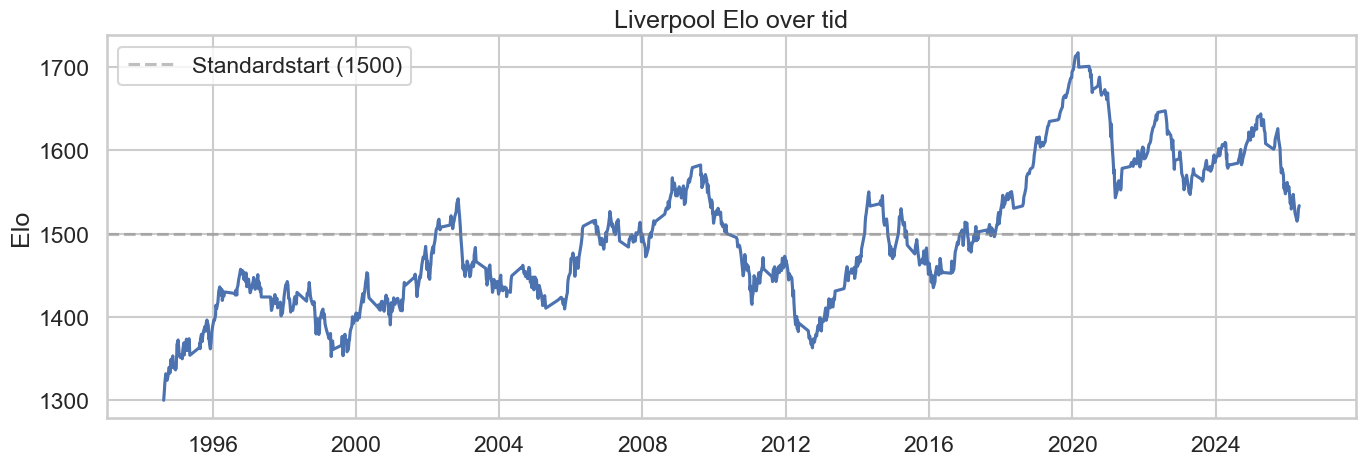

In [ ]:
#feature test
# Hvordan har Liverpools Elo utviklet seg over de siste sesongene?
liverpool_elo = (
    pd.concat([
        df_feat[df_feat["home_team"] == "Liverpool"][["date", "home_elo_pre"]].rename(
            columns={"home_elo_pre": "elo"}),
        df_feat[df_feat["away_team"] == "Liverpool"][["date", "away_elo_pre"]].rename(
            columns={"away_elo_pre": "elo"}),
    ])
    .sort_values("date")
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(liverpool_elo["date"], liverpool_elo["elo"])
ax.set_title("Liverpool Elo over tid")
ax.set_ylabel("Elo")
ax.axhline(1500, color="gray", linestyle="--", alpha=0.5, label="Standardstart (1500)")
ax.legend()
plt.tight_layout()
plt.show()